In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

# seed 값 설정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)


In [8]:
# 데이터 불러오기
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()
# input_shape=(행, 열, 색상 또는 흑백) 형식. 입력 이미지가 색상이면 3, 흑백이면 1
#즉 CNN을 쓰기 전에는 1차원 배열로 만들어 주었지만 CNN에서는 image 정보를 그대로 살림  지정.

In [9]:
X_train.shape

(60000, 28, 28)

In [10]:
X_test.shape

(10000, 28, 28)

In [5]:
# input_shape=(행, 열, 색상 또는 흑백) 형식. 입력 이미지가 색상이면 3, 흑백이면 1
#즉 CNN을 쓰기 전에는 1차원 배열로 만들어 주었지만 CNN에서는 image 정보를 그대로 살림  지정.
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255
Y_train = tf.keras.utils.to_categorical(Y_train)
Y_test = tf.keras.utils.to_categorical(Y_test)

# 컨볼루션 신경망 설정
model = Sequential()
#model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu'))
model.add(Input(shape = (28, 28, 1)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))


In [6]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 모델 최적화 설정
MODEL_DIR = './model_CNN_M/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath="./model_CNN_M/{epoch:02d}-{val_loss:.4f}.keras"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1,
                               save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델의 실행
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=30,    
         batch_size=200, verbose=0, callbacks=[early_stopping_callback,checkpointer])



Epoch 1: val_loss improved from inf to 0.05660, saving model to ./model_CNN_M/01-0.0566.keras

Epoch 2: val_loss improved from 0.05660 to 0.04004, saving model to ./model_CNN_M/02-0.0400.keras

Epoch 3: val_loss improved from 0.04004 to 0.03329, saving model to ./model_CNN_M/03-0.0333.keras

Epoch 4: val_loss improved from 0.03329 to 0.03274, saving model to ./model_CNN_M/04-0.0327.keras

Epoch 5: val_loss improved from 0.03274 to 0.03057, saving model to ./model_CNN_M/05-0.0306.keras

Epoch 6: val_loss did not improve from 0.03057

Epoch 7: val_loss improved from 0.03057 to 0.02972, saving model to ./model_CNN_M/07-0.0297.keras

Epoch 8: val_loss did not improve from 0.02972

Epoch 9: val_loss did not improve from 0.02972

Epoch 10: val_loss did not improve from 0.02972

Epoch 11: val_loss did not improve from 0.02972

Epoch 12: val_loss improved from 0.02972 to 0.02833, saving model to ./model_CNN_M/12-0.0283.keras

Epoch 13: val_loss did not improve from 0.02833

Epoch 14: val_loss

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9899 - loss: 0.0393

 Test Accuracy: 0.9924


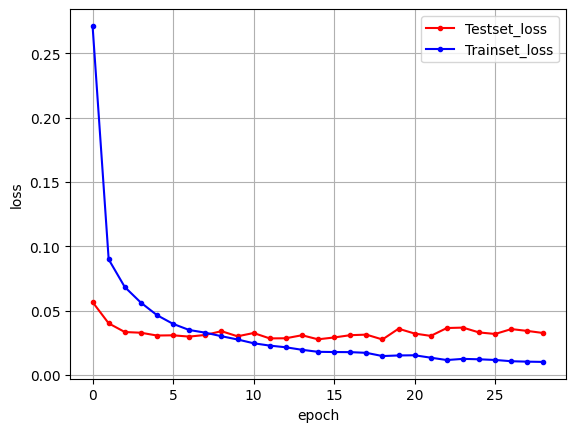

In [7]:
# 테스트 정확도 출력 
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, Y_test) [1]))

# 테스트셋의 오차
y_vloss = history.history['val_loss']

# 학습셋의 오차
y_loss = history.history['loss']

# 그래프로 표현
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()
